# 딥러닝 기초 1일차 실습과제: 퍼셉트론과 활성화 함수

## 과제 개요
이 과제에서는 신경망의 기본 단위인 **퍼셉트론**을 구현하고, 다양한 **활성화 함수**의 특성을 비교합니다.

### 학습 목표
1. 퍼셉트론의 구조와 원리 이해
2. 논리 게이트(AND, OR, NAND, XOR) 구현
3. 다층 퍼셉트론의 필요성 이해
4. 활성화 함수(Sigmoid, ReLU, Tanh) 비교

### 예상 소요 시간
약 **1시간**

### 제출물
- 완성된 노트북 파일 (.ipynb)
- 모든 과제 답변 작성 완료

---

## Part 0: 환경 설정

In [1]:
# 필요한 라이브러리 import
import numpy as np
import matplotlib.pyplot as plt

# 재현성을 위한 시드 설정
np.random.seed(42)

print("환경 설정 완료!")

환경 설정 완료!


---

## Part 1: 퍼셉트론 기초

### 퍼셉트론이란?
- 입력값에 가중치를 곱하고 편향을 더한 후, 활성화 함수를 적용하는 가장 단순한 신경망 단위
- 수식: $y = f(w_1 x_1 + w_2 x_2 + b)$

### 논리 게이트 진리표
| $x_1$ | $x_2$ | AND | OR | NAND | XOR |
|:-----:|:-----:|:---:|:--:|:----:|:---:|
| 0 | 0 | 0 | 0 | 1 | 0 |
| 0 | 1 | 0 | 1 | 1 | 1 |
| 1 | 0 | 0 | 1 | 1 | 1 |
| 1 | 1 | 1 | 1 | 0 | 0 |

In [5]:
# ============================================
# 퍼셉트론 기본 구현
# ============================================

def step_function(x):
    """계단 함수: 0보다 크면 1, 아니면 0"""
    return 1 if x > 0 else 0

def perceptron(x1, x2, w1, w2, b):
    """
    퍼셉트론 연산
    - x1, x2: 입력값
    - w1, w2: 가중치 (입력의 중요도)
    - b: 편향 (발화 임계값 조절)
    """
    z = w1 * x1 + w2 * x2 + b  # 가중합 계산
    return step_function(z)     # 활성화 함수 적용

# AND 게이트: 둘 다 1일 때만 1
def and_gate(x1, x2):
    w1, w2, b = 0.5, 0.5, -0.7
    return perceptron(x1, x2, w1, w2, b)

# OR 게이트: 하나라도 1이면 1
def or_gate(x1, x2):
    w1, w2, b = 0.5, 0.5, -0.3
    return perceptron(x1, x2, w1, w2, b)

# 테스트
print("AND 게이트 테스트:")
for x1, x2 in [(0,0), (0,1), (1,0), (1,1)]:
    print(f"  AND({x1}, {x2}) = {and_gate(x1, x2)}")

print("\nOR 게이트 테스트:")
for x1, x2 in [(0,0), (0,1), (1,0), (1,1)]:
    print(f"  OR({x1}, {x2}) = {or_gate(x1, x2)}")

AND 게이트 테스트:
  AND(0, 0) = 0
  AND(0, 1) = 0
  AND(1, 0) = 0
  AND(1, 1) = 1

OR 게이트 테스트:
  OR(0, 0) = 0
  OR(0, 1) = 1
  OR(1, 0) = 1
  OR(1, 1) = 1


### [필수] 과제 1-1: NAND 게이트 구현하기

NAND 게이트는 AND 게이트의 반대입니다. 위의 진리표를 참고하여 NAND 게이트를 구현하세요.

**힌트**: AND 게이트의 출력을 뒤집으면 NAND가 됩니다. 가중치나 편향의 부호를 바꿔보세요!

In [6]:
# [과제 1-1] NAND 게이트 구현
# TODO: 가중치(w1, w2)와 편향(b)을 설정하여 NAND 게이트를 완성하세요

def nand_gate(x1, x2):
    # TODO: 아래 None 값을 적절한 숫자로 변경하세요
    w1 = -0.5  # 가중치 1
    w2 = -0.5  # 가중치 2
    b = 0.7 # 편향
    
    return perceptron(x1, x2, w1, w2, b)

# 테스트 - 결과가 NAND 진리표와 일치하는지 확인
print("NAND 게이트 테스트:")
print("기대값: NAND(0,0)=1, NAND(0,1)=1, NAND(1,0)=1, NAND(1,1)=0")
print()
for x1, x2 in [(0,0), (0,1), (1,0), (1,1)]:
    result = nand_gate(x1, x2)
    print(f"  NAND({x1}, {x2}) = {result}")

NAND 게이트 테스트:
기대값: NAND(0,0)=1, NAND(0,1)=1, NAND(1,0)=1, NAND(1,1)=0

  NAND(0, 0) = 1
  NAND(0, 1) = 1
  NAND(1, 0) = 1
  NAND(1, 1) = 0


---

## Part 2: XOR 문제와 다층 퍼셉트론

XOR 게이트는 단일 퍼셉트론으로 구현할 수 없습니다. 왜일까요?

- XOR: 입력이 서로 다를 때 1, 같을 때 0
- 단일 퍼셉트론은 **하나의 직선**으로만 분류 가능 (선형 분리)
- XOR은 직선 하나로 분류할 수 없음 -> **다층 퍼셉트론(MLP)** 필요!

In [7]:
# XOR 게이트 구현 (다층 퍼셉트론 개념)
# XOR = AND(NAND(x1, x2), OR(x1, x2))

def nand_gate_solution(x1, x2):
    """NAND 게이트 정답"""
    w1, w2, b = -0.5, -0.5, 0.7
    return perceptron(x1, x2, w1, w2, b)

def xor_gate(x1, x2):
    """
    XOR 게이트 - 2층 퍼셉트론으로 구현
    
    구조:
    입력층: x1, x2
    은닉층: NAND(x1,x2), OR(x1,x2)  <- 2개의 퍼셉트론
    출력층: AND(은닉1, 은닉2)       <- 1개의 퍼셉트론
    """
    # 은닉층 (첫 번째 층)
    s1 = nand_gate_solution(x1, x2)  # 첫 번째 뉴런
    s2 = or_gate(x1, x2)              # 두 번째 뉴런
    
    # 출력층 (두 번째 층)
    y = and_gate(s1, s2)
    
    return y

# 테스트
print("XOR 게이트 테스트 (다층 퍼셉트론):")
print("기대값: XOR(0,0)=0, XOR(0,1)=1, XOR(1,0)=1, XOR(1,1)=0")
print()
for x1, x2 in [(0,0), (0,1), (1,0), (1,1)]:
    result = xor_gate(x1, x2)
    print(f"  XOR({x1}, {x2}) = {result}")

print("\n=> 여러 퍼셉트론을 쌓으면 비선형 문제도 해결할 수 있습니다!")
print("   이것이 바로 '다층 퍼셉트론(MLP)'의 핵심 아이디어입니다.")

XOR 게이트 테스트 (다층 퍼셉트론):
기대값: XOR(0,0)=0, XOR(0,1)=1, XOR(1,0)=1, XOR(1,1)=0

  XOR(0, 0) = 0
  XOR(0, 1) = 1
  XOR(1, 0) = 1
  XOR(1, 1) = 0

=> 여러 퍼셉트론을 쌓으면 비선형 문제도 해결할 수 있습니다!
   이것이 바로 '다층 퍼셉트론(MLP)'의 핵심 아이디어입니다.


### [필수] 과제 2-1: 퍼셉트론 이해도 점검

아래 질문에 **각각 1-2문장**으로 답하세요:

1. 퍼셉트론에서 **가중치(weight)**의 역할은 무엇인가요?
   - 답변: 결과에 얼마나 영향을 주는지 조절하는 값. 해당 값을 조절하여 퍼셉트론의 출력 결정에 더 크게 작용함.

2. 단일 퍼셉트론으로 XOR을 구현할 수 없는 이유는?
   - 답변: and : x1 + x2 > 1.5 -> 1, x1 + x2 <= 1.5 -> 0 이런식으로 and와 or은 특정 기준선 하나로 0과 1을 분리 할 수 있지만 XOR은 하나의 직선 기준선으로 분리할 수 없기때문에 단일 퍼셉트론으로는 구현할 수 없다

---

## Part 3: 활성화 함수 비교

활성화 함수는 신경망에 **비선형성**을 부여합니다. 대표적인 활성화 함수들을 비교해봅시다.

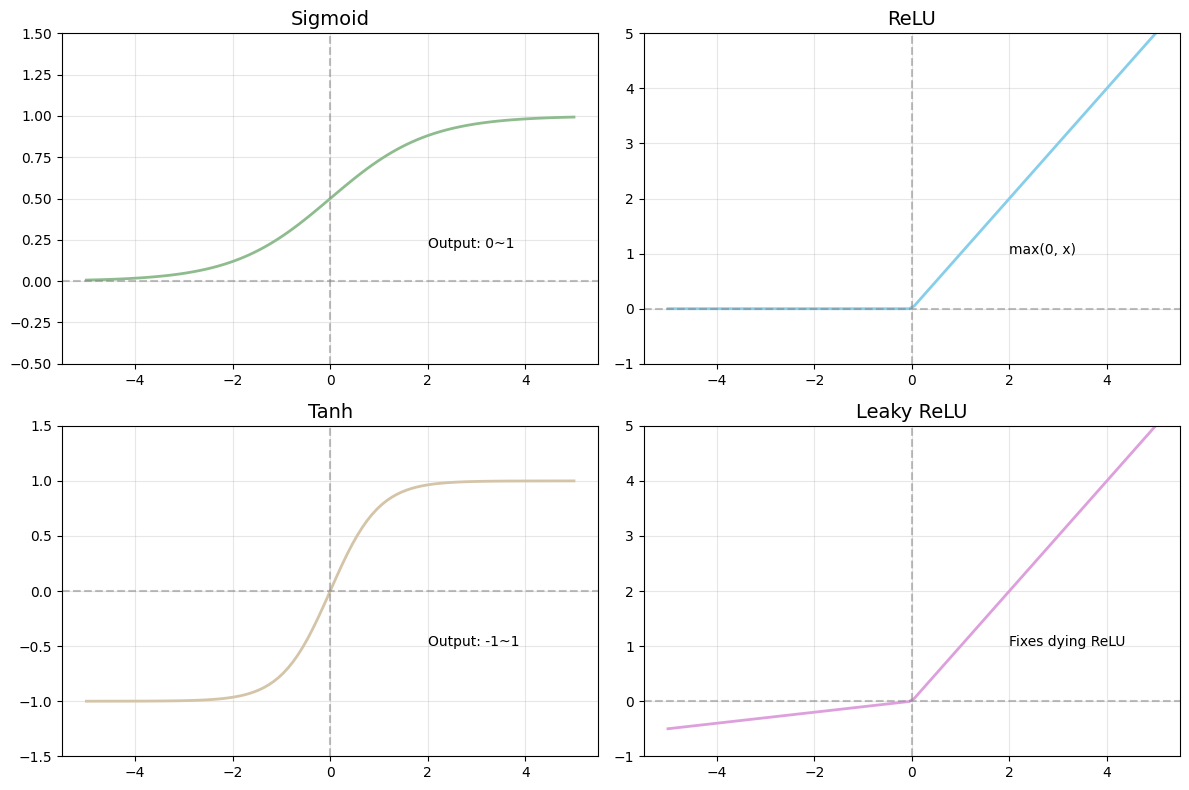

In [8]:
# ============================================
# 활성화 함수 정의
# ============================================

def sigmoid(x):
    """Sigmoid: 출력을 0~1 사이로 압축"""
    return 1 / (1 + np.exp(-x))

def relu(x):
    """ReLU: 음수는 0, 양수는 그대로"""
    return np.maximum(0, x)

def tanh(x):
    """Tanh: 출력을 -1~1 사이로 압축"""
    return np.tanh(x)

def leaky_relu(x, alpha=0.1):
    """Leaky ReLU: 음수에도 작은 기울기 부여"""
    return np.where(x > 0, x, alpha * x)

# 시각화
x = np.linspace(-5, 5, 100)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Sigmoid
axes[0, 0].plot(x, sigmoid(x), color='#8FBC8F', linewidth=2)
axes[0, 0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[0, 0].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
axes[0, 0].set_title('Sigmoid', fontsize=14)
axes[0, 0].set_ylim(-0.5, 1.5)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].text(2, 0.2, 'Output: 0~1', fontsize=10)

# ReLU
axes[0, 1].plot(x, relu(x), color='#87CEEB', linewidth=2)
axes[0, 1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[0, 1].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
axes[0, 1].set_title('ReLU', fontsize=14)
axes[0, 1].set_ylim(-1, 5)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].text(2, 1, 'max(0, x)', fontsize=10)

# Tanh
axes[1, 0].plot(x, tanh(x), color='#D4C4A8', linewidth=2)
axes[1, 0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[1, 0].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
axes[1, 0].set_title('Tanh', fontsize=14)
axes[1, 0].set_ylim(-1.5, 1.5)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].text(2, -0.5, 'Output: -1~1', fontsize=10)

# Leaky ReLU
axes[1, 1].plot(x, leaky_relu(x), color='#DDA0DD', linewidth=2)
axes[1, 1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[1, 1].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
axes[1, 1].set_title('Leaky ReLU', fontsize=14)
axes[1, 1].set_ylim(-1, 5)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].text(2, 1, 'Fixes dying ReLU', fontsize=10)

plt.tight_layout()
plt.show()

In [9]:
# 활성화 함수 특성 비교표 출력
print("=" * 70)
print("활성화 함수 특성 비교")
print("=" * 70)
print(f"{'함수':<12} {'출력 범위':<15} {'장점':<25} {'단점'}")
print("-" * 70)
print(f"{'Sigmoid':<12} {'0 ~ 1':<15} {'확률 해석 가능':<25} {'기울기 소실'}")
print(f"{'ReLU':<12} {'0 ~ inf':<15} {'빠른 학습, 간단':<25} {'Dying ReLU'}")
print(f"{'Tanh':<12} {'-1 ~ 1':<15} {'0 중심':<25} {'기울기 소실'}")
print(f"{'Leaky ReLU':<12} {'-inf ~ inf':<15} {'Dying ReLU 해결':<25} {'alpha 튜닝 필요'}")
print("=" * 70)

활성화 함수 특성 비교
함수           출력 범위           장점                        단점
----------------------------------------------------------------------
Sigmoid      0 ~ 1           확률 해석 가능                  기울기 소실
ReLU         0 ~ inf         빠른 학습, 간단                 Dying ReLU
Tanh         -1 ~ 1          0 중심                      기울기 소실
Leaky ReLU   -inf ~ inf      Dying ReLU 해결             alpha 튜닝 필요


### [필수] 과제 3-1: 활성화 함수 이해도 점검

아래 질문에 답하세요:

1. 은닉층에서 ReLU가 Sigmoid보다 많이 사용되는 이유는?
    w_new = w_old - η × ∂L/∂w
   - case1: Sigmoid가 여러 층에 중첩됨
            → 각 층의 미분값이 최대 0.25
            → 역전파에서 0.25 이하의 값들이 계속 곱해짐
            → 앞쪽 층으로 갈수록 gradient가 0에 가까워짐
            → ∂L/∂w ≈ 0
            → w 조정이 거의 안 됨
   - case2: Sigmoid에 들어가는 z값이 너무 크거나 너무 작음
            → sigmoid 출력이 1 또는 0 근처로 포화됨
            → sigmoid 미분값 σ'(z)이 0에 가까워짐
            → 역전파에서 거의 0인 기울기가 곱해짐
            → ∂L/∂w ≈ 0
            → w 조정이 거의 안 됨

2. 이진 분류 문제의 **출력층**에서 어떤 활성화 함수를 사용해야 하나요? 그 이유는?
   - 답변: sigmoid, 0~1 사이의 값으로 변환해주기에 확률처럼 보여 이를 활용해 threshold를 조정하여 이진분류 출력을 하기쉬움

---

## Part 4: [도전] Softmax 함수 구현

다중 클래스 분류에서 사용하는 Softmax 함수를 직접 구현해보세요.

In [12]:
# [도전 과제] Softmax 함수 구현
# TODO: Softmax 함수를 구현하세요
# 힌트: softmax(x_i) = exp(x_i) / sum(exp(x_j))

def softmax(x):
    """
    Softmax 함수: 입력을 확률 분포로 변환
    - 모든 출력의 합이 1이 됨
    - 다중 클래스 분류의 출력층에서 사용
    """
    # TODO: 구현하세요
    return np.exp(x) / np.sum(np.exp(x))

# 테스트
test_input = np.array([2.0, 1.0, 0.1])
result = softmax(test_input)
print(f"입력: {test_input}")
print(f"Softmax 출력: {result}")
print(f"합계: {np.sum(result):.4f} (1이 되어야 함)")

입력: [2.  1.  0.1]
Softmax 출력: [0.65900114 0.24243297 0.09856589]
합계: 1.0000 (1이 되어야 함)


---

## 1일차 학습 정리

오늘 배운 핵심 내용을 체크해보세요:

- [ ] 퍼셉트론의 구조 (입력, 가중치, 편향, 활성화 함수) 이해
- [ ] AND, OR, NAND 게이트를 퍼셉트론으로 구현 가능
- [ ] XOR은 단일 퍼셉트론으로 불가능 -> 다층 퍼셉트론 필요
- [ ] 활성화 함수의 역할: 비선형성 부여
- [ ] ReLU vs Sigmoid의 차이점 이해

---

## 수고하셨습니다!

### 제출 전 체크리스트
- [ ] 과제 1-1 (NAND 게이트) 완료
- [ ] 과제 2-1 (퍼셉트론 이해) 답변 작성
- [ ] 과제 3-1 (활성화 함수 이해) 답변 작성
- [ ] [선택] 도전 과제 (Softmax 구현)